In [1]:
import glob
import json
import re
from functools import partial

import matplotlib.pyplot as plt
import numpy as np


def calc_mode(data, axis=0):
    bins = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=5), axis=axis, arr=data
    )
    # resolve ties randomly by adding a small random number to the counts
    rand_mat = np.random.random_sample(bins.shape)
    bins = bins + rand_mat
    return np.argmax(bins, axis=axis)


cap_preds_glob = "../../examples/output/CAP/predictions*_c.npz"
cap_preds_files = sorted(glob.glob(cap_preds_glob))
print(cap_preds_files)

keys_per_run_per_sr = {}
for pred_file in cap_preds_files:
    f_handle = np.load(pred_file)
    keys = f_handle.files

    for k in keys:
        model_run = k.split("#")[1]
        sleep_stage_sr = int(k.split('#')[2])
        if model_run not in keys_per_run_per_sr:
            keys_per_run_per_sr[model_run] = {}
        if sleep_stage_sr not in keys_per_run_per_sr[model_run]:
            keys_per_run_per_sr[model_run][sleep_stage_sr] = []
        keys_per_run_per_sr[model_run][sleep_stage_sr].append([f_handle, k])

epoch_sr = 128 * 30
n_classes = 5
feature_block_duration = int(1.5 * 60 * 2)  # in epochs
possible_triplets = [f"{i}{j}{k}" for i in range(n_classes) for j in range(n_classes) for k in range(n_classes)
                     if i != j and j != k]


def calc_features(sleep_sr, preds_dict, preds_per_epoch):
    features = {}

    for rec in preds_dict.keys():
        preds = preds_dict[rec]

        sleep_start = np.where(preds_per_epoch[rec] != 0)[0][0]
        sleep_end = np.where(preds_per_epoch[rec] != 0)[0][-1]

        features[rec] = []
        for i in range(sleep_start, sleep_end, feature_block_duration):
            features[rec].append([0] * len(possible_triplets))
            features_block = preds[i * sleep_sr:min(i + feature_block_duration, sleep_end) * sleep_sr]
            features_block_1r = np.r_[features_block[0], features_block[:-1]]
            features_block_1l = np.r_[features_block[1:], features_block[-1]]

            # find triplets with a different element in the middle
            triplet_mask = np.where(((features_block - features_block_1r) != 0)
                                    & ((features_block - features_block_1l) != 0))[0]

            for trip_idx in triplet_mask:
                trip_str = f"{features_block[trip_idx - 1]}{features_block[trip_idx]}{features_block[trip_idx + 1]}"
                features[rec][-1][possible_triplets.index(trip_str)] += 1

    return features

['../../examples/output/CAP/predictions_c.npz']


In [2]:
subj_insomnia_dict = {}
for model_dict in keys_per_run_per_sr.values():
    for sr_dict in model_dict.values():
        for _, f in sr_dict:
            s_id = f.split("#")[0]
            coh = re.split("\d", s_id)[0]
            if coh == "n":
                subj_insomnia_dict[s_id] = 0
            if coh == "ins":
                subj_insomnia_dict[s_id] = 1

subj_insomnia_dict

{'ins9': 1,
 'n9': 0,
 'n13': 0,
 'n8': 0,
 'ins6': 1,
 'n10': 0,
 'ins4': 1,
 'ins8': 1,
 'n15': 0,
 'n2': 0,
 'n1': 0,
 'n5': 0,
 'ins5': 1,
 'n7': 0,
 'n14': 0,
 'n11': 0,
 'n16': 0,
 'ins3': 1,
 'n4': 0,
 'ins2': 1,
 'n6': 0,
 'ins1': 1,
 'ins7': 1,
 'n12': 0,
 'n3': 0}

In [3]:
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ProcessPoolExecutor


def train_and_predict(features, n_exps):
    x_data = []
    y_data = []
    subject_mapping = []

    for subject_name, subj_features in features.items():
        if subject_name not in subj_insomnia_dict:
            print(f"No insomnia label for {subject_name}")
            continue
        x_data.extend(subj_features)
        y_data.extend([subj_insomnia_dict[subject_name]] * len(subj_features))
        subject_mapping.extend([subject_name] * len(subj_features))

    x_data = np.array(x_data)
    y_data = np.array(y_data)
    subject_mapping = np.array(subject_mapping)

    label_insomnia = []
    predict_insomnia = []
    for run_num in range(n_exps):
        label_insomnia.append([])
        predict_insomnia.append([])

        with ProcessPoolExecutor(max_workers=32) as executor:
            partial_f = partial(fit_and_predict, run_num, x_data, y_data, subject_mapping)
            results = list(executor.map(partial_f, np.unique(subject_mapping)))
            for label, pred in results:
                label_insomnia[-1].append(label)
                predict_insomnia[-1].append(pred)

    return label_insomnia, predict_insomnia


with open("rnd_parameter_map_rndfcls.json", "r") as f:
    rnd_parameter_map = json.load(f)


def fit_and_predict(run_num, x_data, y_data, subject_mapping, subj):
    x_train = x_data[subject_mapping != subj].copy()
    y_train = y_data[subject_mapping != subj].copy()
    x_test = x_data[subject_mapping == subj].copy()
    y_test = y_data[subject_mapping == subj].copy()

    clf = RandomForestClassifier(n_estimators=200, criterion="gini", class_weight="balanced",
                                 max_depth=rnd_parameter_map[run_num]["max_tree_depth"],
                                 min_samples_leaf=rnd_parameter_map[run_num]["min_samples_leaf"],
                                 min_samples_split=rnd_parameter_map[run_num]["min_samples_split"],
                                 max_features=rnd_parameter_map[run_num]["max_features"])
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)
    return y_test[0], np.mean(y_pred)

In [4]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

n_exps = 50

mf1_scores = {}
for model_run, files_per_sr in keys_per_run_per_sr.items():
    print(f"Model epoch: {model_run}")
    preds_per_epoch = {}
    for file in files_per_sr[1]:  # 1 = 30s epochs
        preds_per_epoch[file[1].split("#")[0]] = file[0][file[1]]
    mf1_scores[model_run] = {}
    for sleep_stage_sr, files in files_per_sr.items():
        preds_per_window_sr = {}
        for file in files:
            preds_per_window_sr[file[1].split("#")[0]] = file[0][file[1]]
        features = calc_features(sleep_stage_sr, preds_per_window_sr, preds_per_epoch)
        label_insomnia, predict_insomnia = train_and_predict(features, n_exps)

        predict_insomnia = np.array(predict_insomnia)
        label_insomnia = np.array(label_insomnia)

        predict_insomnia_bin = (predict_insomnia > 0.5).astype(int)
        predict_insomnia_bin[predict_insomnia == 0.5] = np.random.randint(0, 2, size=np.sum(predict_insomnia == 0.5))

        f1_array = []
        for i_exp in range(n_exps):
            cm = confusion_matrix(label_insomnia[i_exp], predict_insomnia_bin[i_exp])
            precs, recs, f1s, _ = precision_recall_fscore_support(label_insomnia[i_exp], predict_insomnia_bin[i_exp],
                                                                  average=None, zero_division=1)
            f1_array.append(np.mean(f1s))

        print(f"{sleep_stage_sr} sleep stages per epoch")
        print(f"Avg. Makro F1: {np.mean(f1_array)}")
        print(f"Std. Makro F1: {np.std(f1_array)}")
        print()
        mf1_scores[model_run][sleep_stage_sr] = [float(a) for a in f1_array]


Model epoch: anysleep-run1
No insomnia label for plm9
No insomnia label for plm8
No insomnia label for nfle13
No insomnia label for rbd14
No insomnia label for rbd12
No insomnia label for nfle26
No insomnia label for nfle40
No insomnia label for nfle7
No insomnia label for rbd18
No insomnia label for rbd8
No insomnia label for nfle10
No insomnia label for rbd7
No insomnia label for narco3
No insomnia label for nfle38
No insomnia label for nfle11
No insomnia label for nfle5
No insomnia label for plm10
No insomnia label for nfle37
No insomnia label for narco2
No insomnia label for nfle24
No insomnia label for rbd13
No insomnia label for sdb3
No insomnia label for rbd19
No insomnia label for nfle20
No insomnia label for nfle15
No insomnia label for rbd15
No insomnia label for nfle25
No insomnia label for nfle21
No insomnia label for narco1
No insomnia label for rbd10
No insomnia label for nfle30
No insomnia label for nfle17
No insomnia label for rbd5
No insomnia label for rbd17
No insomni

[[15  1]
 [ 8  1]]
[[14  2]
 [ 6  3]]
[[15  1]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 8  1]]
[[15  1]
 [ 6  3]]
[[15  1]
 [ 4  5]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[16  0]
 [ 7  2]]
[[15  1]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[16  0]
 [ 6  3]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 5  4]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 4  5]]
[[14  2]
 [ 4  5]]
[[15  1]
 [ 8  1]]
[[14  2]
 [ 8  1]]
[[13  3]
 [ 7  2]]
[[14  2]
 [ 8  1]]
[[14  2]
 [ 4  5]]
[[14  2]
 [ 4  5]]
[[14  2]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 4  5]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 4  5]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[13  3]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 6  3]]
1 sleep stages per epoch
Avg. Makro F1: 0.61331479

[[13  3]
 [ 5  4]]
[[13  3]
 [ 6  3]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[13  3]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[13  3]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 6  3]]
[[13  3]
 [ 5  4]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 6  3]]
[[15  1]
 [ 6  3]]
[[13  3]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[15  1]
 [ 6  3]]
[[15  1]
 [ 7  2]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[13  3]
 [ 7  2]]
[[14  2]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[13  3]
 [ 7  2]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 6  3]]
2 sleep stages per epoch
Avg. Makro F1: 0.58694384

[[13  3]
 [ 6  3]]
[[13  3]
 [ 4  5]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[13  3]
 [ 5  4]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 4  5]]
[[14  2]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[15  1]
 [ 7  2]]
[[14  2]
 [ 7  2]]
[[13  3]
 [ 5  4]]
[[13  3]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[15  1]
 [ 4  5]]
[[16  0]
 [ 4  5]]
[[13  3]
 [ 5  4]]
[[16  0]
 [ 5  4]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 4  5]]
[[14  2]
 [ 7  2]]
[[15  1]
 [ 6  3]]
[[14  2]
 [ 7  2]]
[[14  2]
 [ 5  4]]
[[13  3]
 [ 5  4]]
[[13  3]
 [ 5  4]]
[[13  3]
 [ 4  5]]
[[13  3]
 [ 7  2]]
[[16  0]
 [ 7  2]]
[[16  0]
 [ 7  2]]
[[15  1]
 [ 8  1]]
[[15  1]
 [ 4  5]]
[[13  3]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 6  3]]
[[16  0]
 [ 5  4]]
[[13  3]
 [ 6  3]]
[[13  3]
 [ 5  4]]
[[14  2]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[14  2]
 [ 5  4]]
[[16  0]
 [ 5  4]]
[[14  2]
 [ 5  4]]
[[16  0]
 [ 6  3]]
[[13  3]
 [ 6  3]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 5  4]]
[[14  2]
 [ 4  5]]
[[14  2]
 [ 5  4]]
[[15  1]
 [ 5  4]]
4 sleep stages per epoch
Avg. Makro F1: 0.64454718

No insomnia label for plm9
No insomnia label for plm8
No insomnia label for nfle13
No insomnia label for rbd14
No insomnia label for rbd12
No insomnia label for nfle26
No insomnia label for nfle40
No insomnia label for nfle7
No insomnia label for rbd18
No insomnia label for rbd8
No insomnia label for nfle10
No insomnia label for rbd7
No insomnia label for narco3
No insomnia label for nfle38
No insomnia label for nfle11
No insomnia label for nfle5
No insomnia label for plm10
No insomnia label for nfle37
No insomnia label for narco2
No insomnia label for nfle24
No insomnia label for rbd13
No insomnia label for sdb3
No insomnia label for rbd19
No insomnia label for nfle20
No insomnia label for nfle15
No insomnia label for rbd15
No insomnia label for nfle25
No insomnia label for nfle21
No insomnia label for narco1
No insomnia label for rbd10
No insomnia label for nfle30
No insomnia label for nfle17
No insomnia label for rbd5
No insomnia label for rbd17
No insomnia label for nfle29
No insom

...

[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[14  2]
 [ 2  7]]
[[14  2]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
960 sleep stages per epoch
Avg. Makro F1: 0.787384

No insomnia label for plm9
No insomnia label for plm8
No insomnia label for nfle13
No insomnia label for rbd14
No insomnia label for rbd12
No insomnia label for nfle26
No insomnia label for nfle40
No insomnia label for nfle7
No insomnia label for rbd18
No insomnia label for rbd8
No insomnia label for nfle10
No insomnia label for rbd7
No insomnia label for narco3
No insomnia label for nfle38
No insomnia label for nfle11
No insomnia label for nfle5
No insomnia label for plm10
No insomnia label for nfle37
No insomnia label for narco2
No insomnia label for nfle24
No insomnia label for rbd13
No insomnia label for sdb3
No insomnia label for rbd19
No insomnia label for nfle20
No insomnia label for nfle15
No insomnia label for rbd15
No insomnia label for nfle25
No insomnia label for nfle21
No insomnia label for narco1
No insomnia label for rbd10
No insomnia label for nfle30
No insomnia label for nfle17
No insomnia label for rbd5
No insomnia label for rbd17
No insomnia label for nfle29
No insom

[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[14  2]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[14  2]
 [ 3  6]]
[[14  2]
 [ 3  6]]
[[14  2]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[14  2]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
[[13  3]
 [ 2  7]]
1920 sleep stages per epoch
Avg. Makro F1: 0.76491

No insomnia label for plm9
No insomnia label for plm8
No insomnia label for nfle13
No insomnia label for rbd14
No insomnia label for rbd12
No insomnia label for nfle26
No insomnia label for nfle40
No insomnia label for nfle7
No insomnia label for rbd18
No insomnia label for rbd8
No insomnia label for nfle10
No insomnia label for rbd7
No insomnia label for narco3
No insomnia label for nfle38
No insomnia label for nfle11
No insomnia label for nfle5
No insomnia label for plm10
No insomnia label for nfle37
No insomnia label for narco2
No insomnia label for nfle24
No insomnia label for rbd13
No insomnia label for sdb3
No insomnia label for rbd19
No insomnia label for nfle20
No insomnia label for nfle15
No insomnia label for rbd15
No insomnia label for nfle25
No insomnia label for nfle21
No insomnia label for narco1
No insomnia label for rbd10
No insomnia label for nfle30
No insomnia label for nfle17
No insomnia label for rbd5
No insomnia label for rbd17
No insomnia label for nfle29
No insom

[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[13  3]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
[[12  4]
 [ 3  6]]
3840 sleep stages per epoch
Avg. Makro F1: 0.70655

In [5]:
print(mf1_scores)

{'anysleep-run1': {1: [0.4755244755244755, 0.6031746031746031, 0.7023809523809523, 0.6031746031746031, 0.6361746361746362, 0.5322245322245323, 0.5614035087719298, 0.45175438596491224, 0.6361746361746362, 0.7619047619047619, 0.6361746361746362, 0.6031746031746031, 0.592074592074592, 0.7023809523809523, 0.6031746031746031, 0.6666666666666667, 0.6710526315789473, 0.5614035087719298, 0.5614035087719298, 0.6666666666666667, 0.7023809523809523, 0.5614035087719298, 0.7619047619047619, 0.7242647058823529, 0.4755244755244755, 0.45175438596491224, 0.503968253968254, 0.45175438596491224, 0.7242647058823529, 0.7242647058823529, 0.6666666666666667, 0.6031746031746031, 0.5322245322245323, 0.5614035087719298, 0.7242647058823529, 0.6361746361746362, 0.6666666666666667, 0.5614035087719298, 0.7023809523809523, 0.6361746361746362, 0.7242647058823529, 0.5614035087719298, 0.7023809523809523, 0.6031746031746031, 0.6666666666666667, 0.503968253968254, 0.5322245322245323, 0.6361746361746362, 0.532224532224532

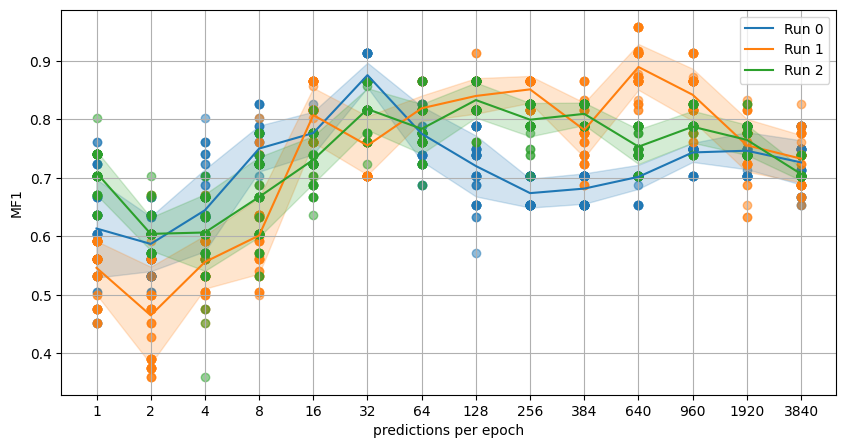

In [6]:
plt.figure(figsize=(10, 5))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, (model_run, mf1_scores_epoch) in enumerate(mf1_scores.items()):
    c = colors[i % len(colors)]
    means_to_plot = np.array(list(mf1_scores_epoch.values())).mean(axis=1)
    stds_to_plot = np.array(list(mf1_scores_epoch.values())).std(axis=1)
    plt.plot(range(len(mf1_scores_epoch)), means_to_plot, label=f"Run {i}", color=c)
    plt.fill_between(range(len(mf1_scores_epoch)), means_to_plot - stds_to_plot, means_to_plot + stds_to_plot,
                     alpha=0.2, color=c)
    plt.scatter(np.repeat(range(len(mf1_scores_epoch)), n_exps), np.array(list(mf1_scores_epoch.values())).flatten(),
                alpha=0.5, color=c)

first_key = next(iter(mf1_scores))
plt.xticks(range(len(mf1_scores[first_key])), list(mf1_scores[first_key].keys()))
plt.grid()
plt.xlabel("predictions per epoch")
plt.ylabel("MF1")
plt.legend()
plt.show()